[*********************100%***********************]  5 of 5 completed


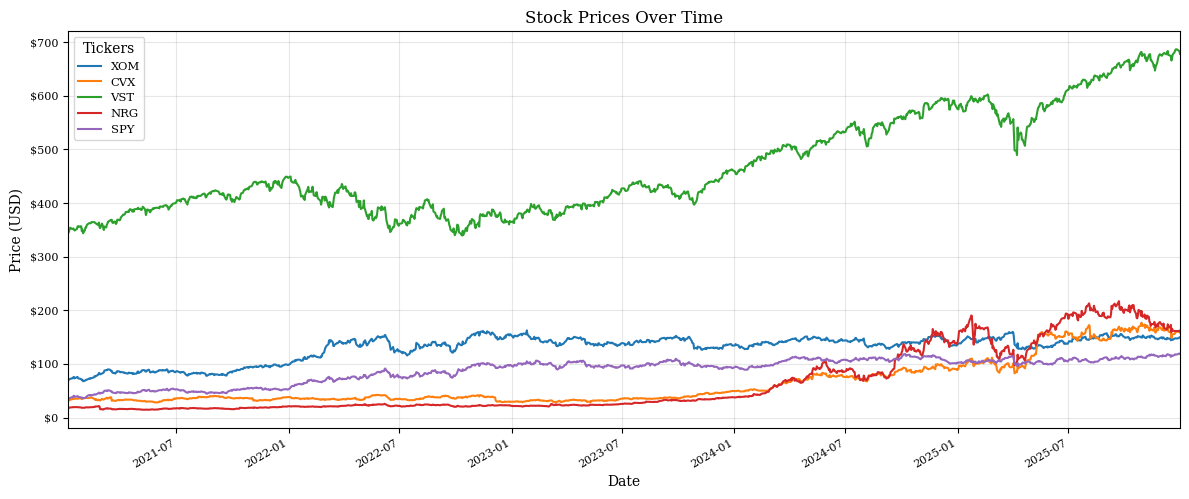

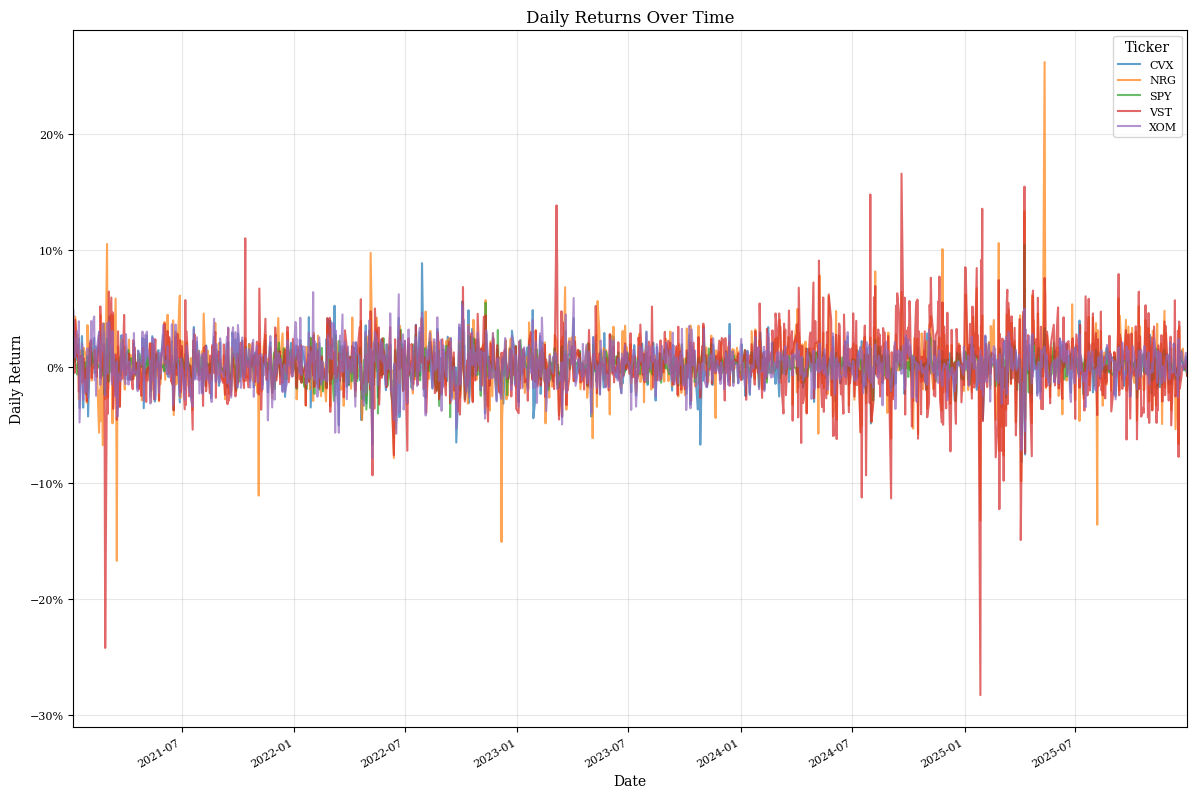

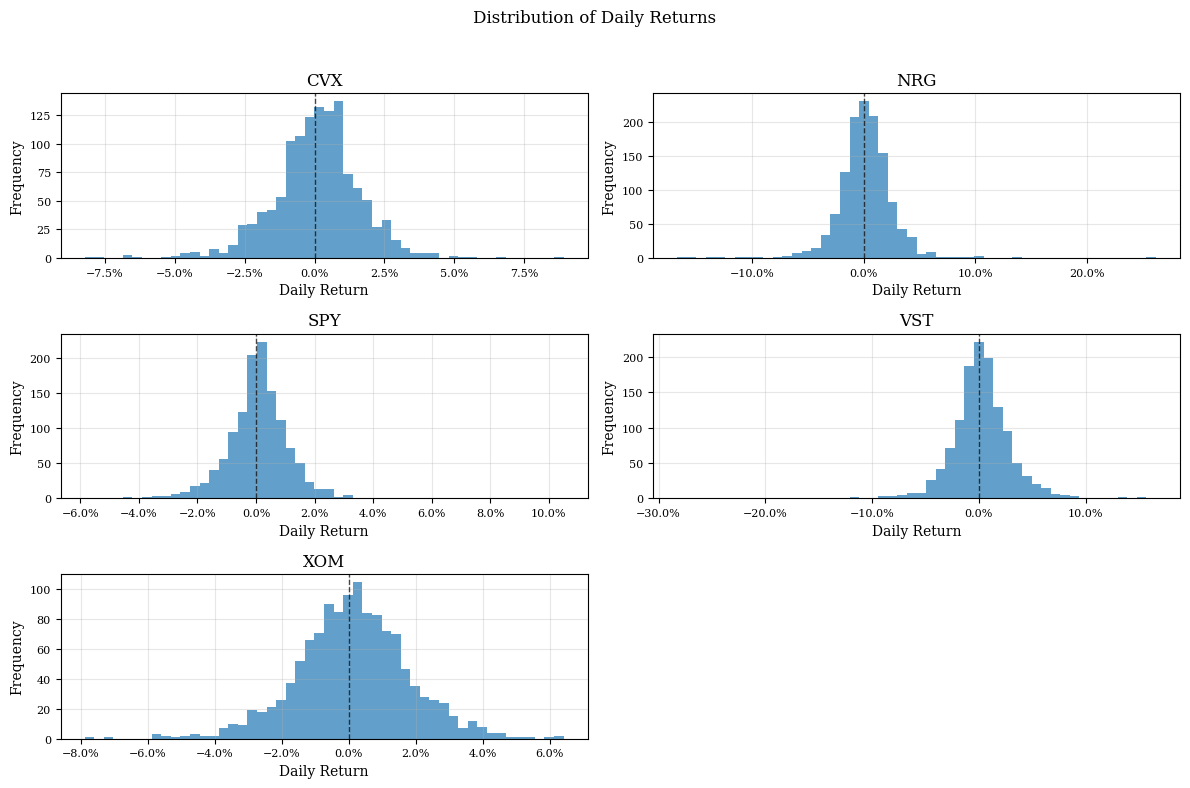

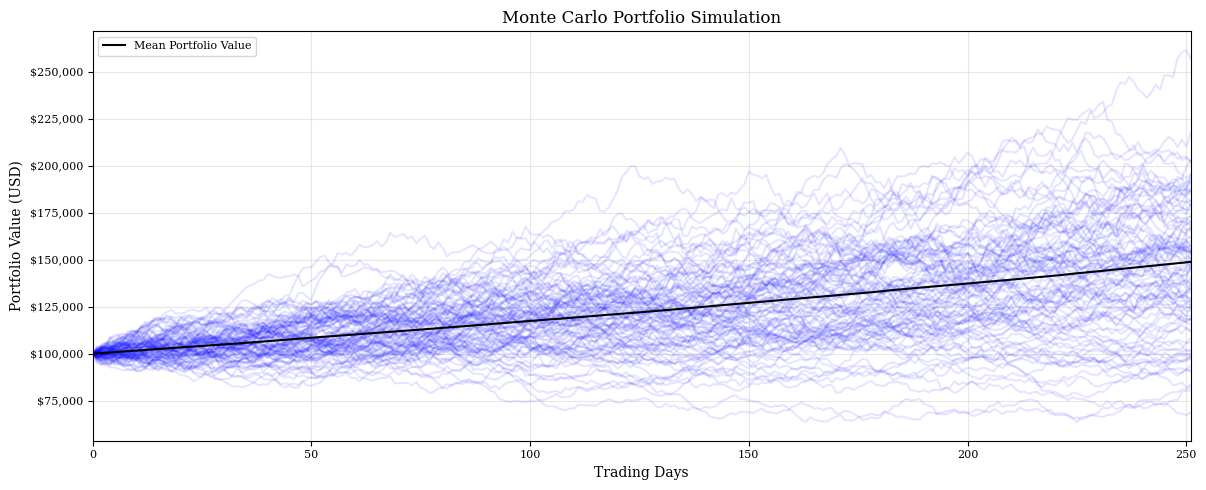

VaR (95% confidence): -7.36%
VaR (95% confidence) in USD: $-7359.43
CVaR (95% confidence): -16.95%


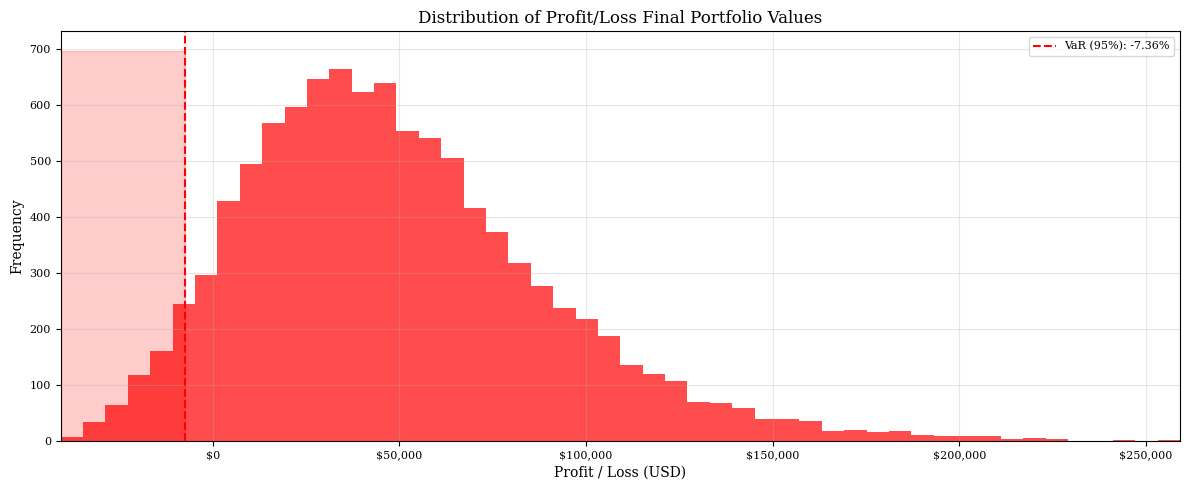

Mean Final Portfolio Value: $148843.28
Median Final Portfolio Value: $143612.93
Standard Deviation of Final Portfolio Values: $40304.61
Minimum Final Portfolio Value: $59210.19
Maximum Final Portfolio Value: $359131.56
Probability of Loss: 8.47%
95% Confidence Interval for Final Portfolio Values: $84407.39 - $243698.63


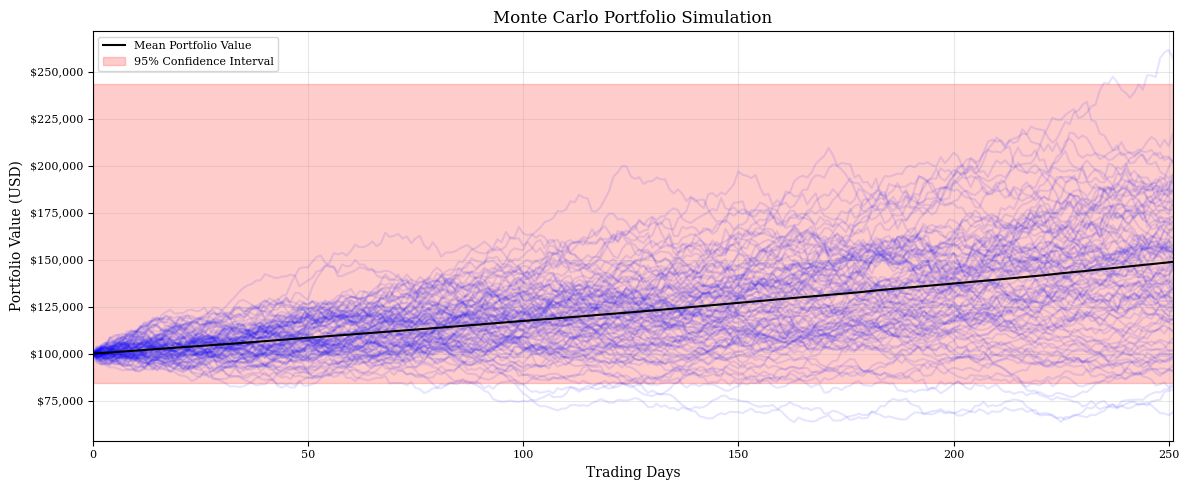

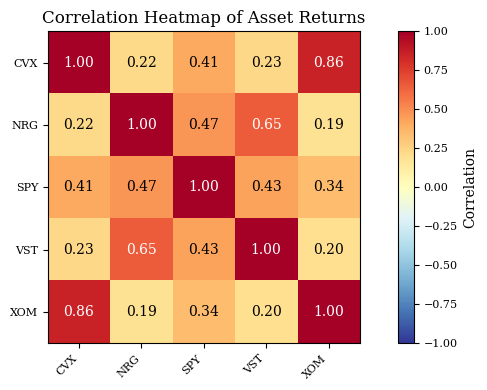

Annualized Portfolio Return: 39.88%
Annualized Portfolio Volatility: 26.82%
Sharpe Ratio: 1.30


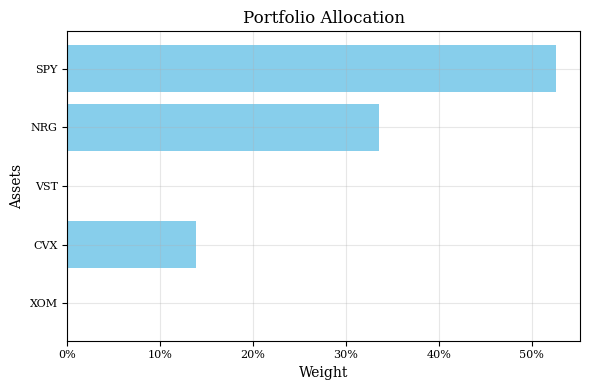

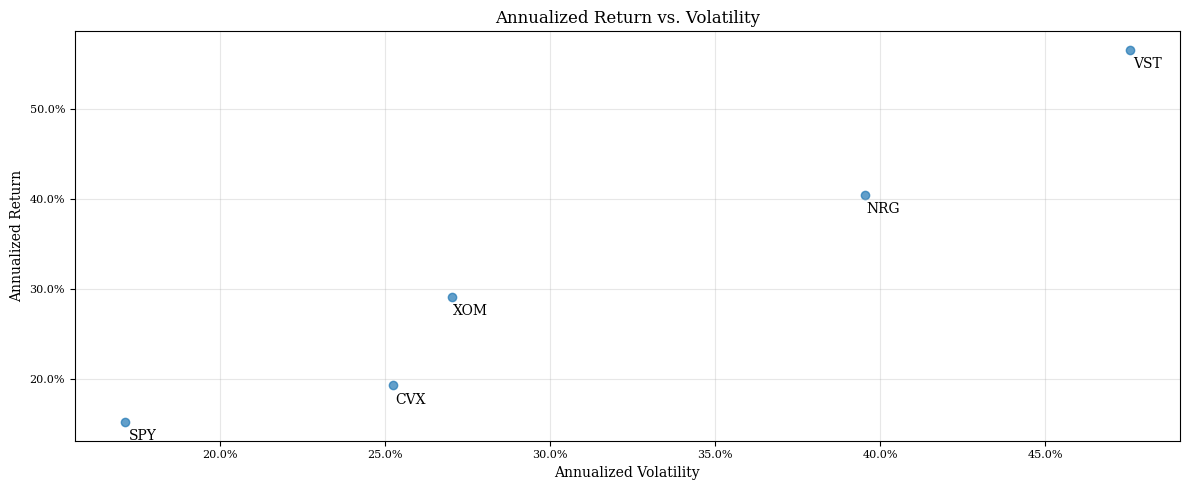

Average Maximum Drawdown: -18.35%
Worst Maximum Drawdown: -50.79%


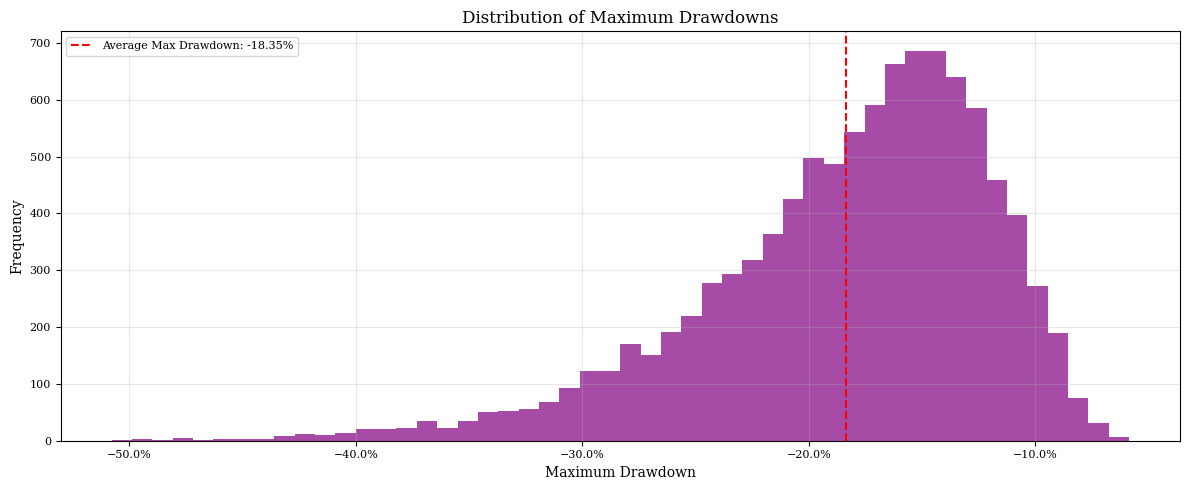

SPY Annualized Return: 15.20%
SPY Annualized Volatility: 17.11%
SPY Sharpe Ratio: 0.60
SPY Maximum Drawdown: -24.50%
SPY VaR (95% confidence): -14.39%
SPY VaR (95% confidence) in USD: $-14385.10
SPY CVaR (95% confidence): -16.41%


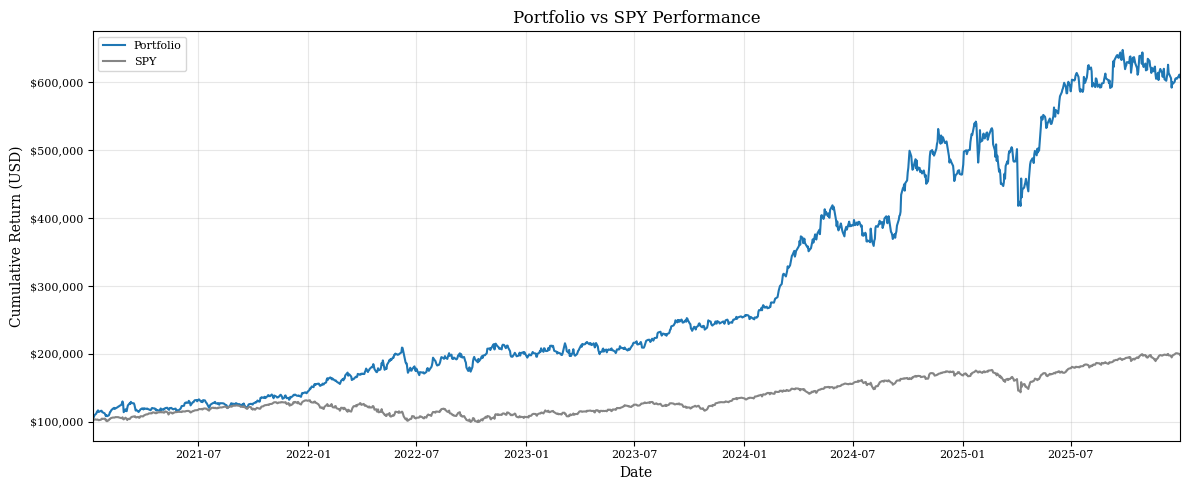

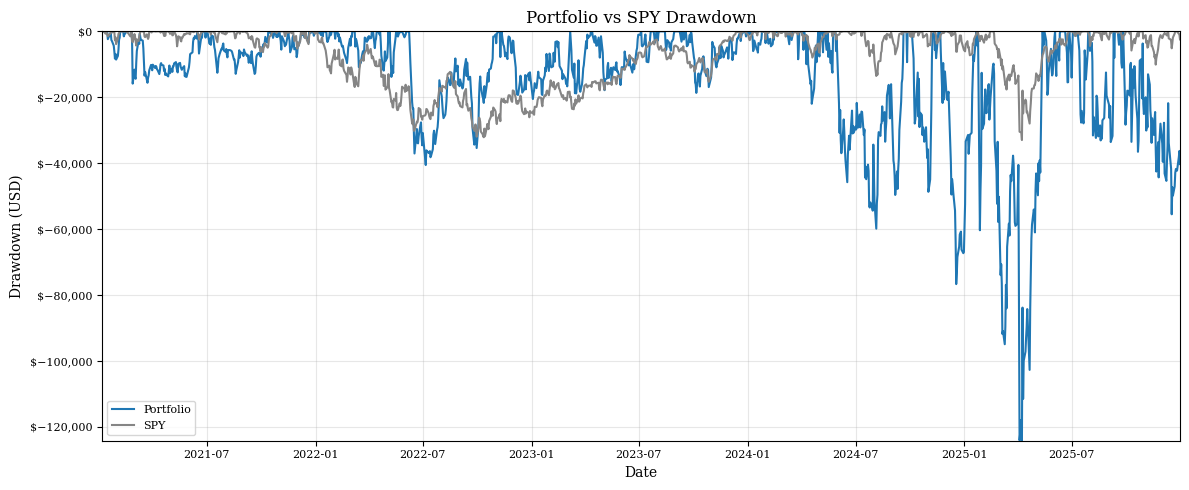

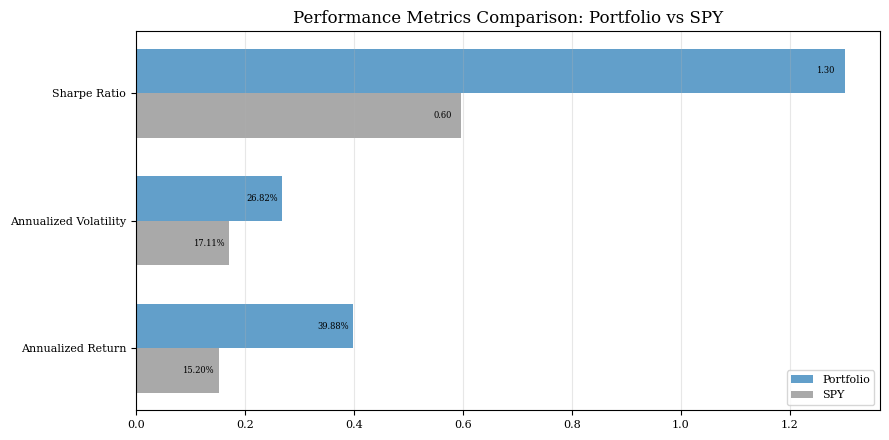

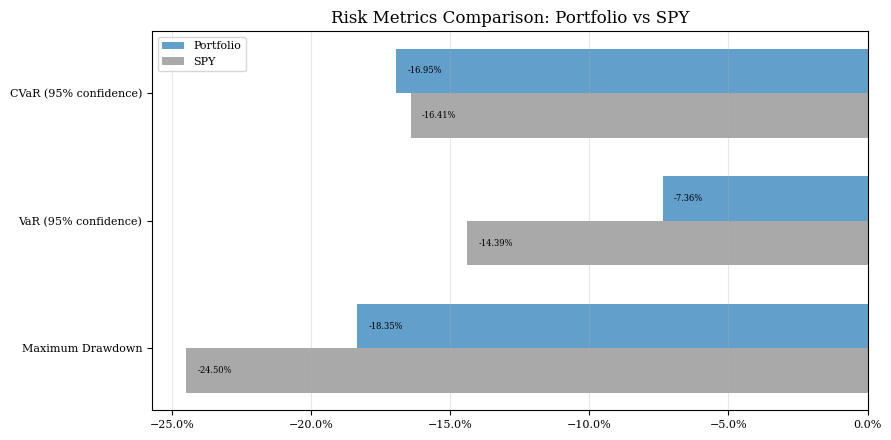

In [5]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from matplotlib.ticker import PercentFormatter
from matplotlib.ticker import StrMethodFormatter
from scipy.optimize import minimize

def style_plot():
    plt.rcParams['axes.labelsize'] = 10
    plt.rcParams['axes.titlesize'] = 12
    plt.rcParams['xtick.labelsize'] = 8
    plt.rcParams['ytick.labelsize'] = 8
    plt.rcParams['legend.fontsize'] = 8
    plt.rcParams['font.family'] = 'serif'
    plt.grid(alpha=0.3)
    plt.tight_layout()

# Portfolio Setup
tickers = ["XOM", "CVX", "VST", "NRG", "SPY"]
prices = yf.download(tickers, start="2021-01-01", end="2026-01-01")["Close"]
prices.head()
prices.describe()
prices.isna().sum()
prices.plot(figsize=(12,5))
plt.title("Stock Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
ax = plt.gca()
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.legend(tickers, loc='upper left', fontsize='small', title='Tickers', title_fontsize='medium')
plt.linewidth = 2
style_plot()
ax.margins(x=0)
plt.savefig("plots/prices.png", dpi=300, bbox_inches='tight')

# Calculate Returns
returns = prices.pct_change().dropna()
returns.head()
returns.describe()
returns.plot(figsize=(12,8), alpha=0.7)
plt.title("Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Return")
style_plot()
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.margins(x=0)
plt.savefig("plots/returns.png", dpi=300, bbox_inches='tight')

axes = returns.hist(bins=50, figsize=(12, 8), alpha=0.7, layout=(3, 2))
for ax in axes.flatten():
    if ax is not None:
        ax.grid(alpha=0.3)
        ax.xaxis.set_major_formatter(PercentFormatter(1))
        ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
        ax.set_xlabel("Daily Return")
        ax.set_ylabel("Frequency")
plt.suptitle("Distribution of Daily Returns")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("plots/returns_distribution.png", dpi=300, bbox_inches='tight')
returns.corr()

# Portfolio
risk_free_rate = 0.05  # Assuming a 5% risk-free rate
mean_returns = returns.mean()
cov_matrix = returns.cov()

def portfolio_performance(weights, mean_returns, cov_matrix):
    ret = np.dot(weights, mean_returns) * 252
    vol = np.sqrt(weights.T @ cov_matrix @ weights) * np.sqrt(252)
    return ret, vol

def negative_sharpe(weights, mean_returns, cov_matrix, risk_free_rate):
    ret, vol = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(ret - risk_free_rate) / vol

num_assets = len(tickers)
constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1}) # Must sum to 100%
bounds = tuple((0, 1) for _ in range(num_assets))
initial_guess = num_assets * [1. / num_assets] # Begins at equal weight
result = minimize(negative_sharpe, initial_guess, args = (mean_returns, cov_matrix, risk_free_rate), method = "SLSQP", bounds = bounds, constraints = constraints)
weight = result.x



# Monte Carlo Simulation
initial_portfolio_value = 100000
num_portfolios = 10000
days = 252
simulated_portfolios = np.zeros((days, num_portfolios))

simulated_portfolios[0] = initial_portfolio_value

for s in range(num_portfolios):
    portfolio = initial_portfolio_value
    simulated_portfolios[0, s] = portfolio
    for day in range(1, days):
        random_returns = np.random.multivariate_normal(mean_returns, cov_matrix)
        portfolio_return = np.dot(random_returns, weight)
        portfolio *= (1 + portfolio_return)
        simulated_portfolios[day, s] = portfolio

# Plotting the Simulated Portfolios
plt.figure(figsize=(12,5))
plt.plot(simulated_portfolios[:, :100], color='blue', alpha=0.1)
mean_portfolio = simulated_portfolios.mean(axis=1)
plt.plot(mean_portfolio, color='black', label='Mean Portfolio Value')
plt.legend()
plt.title("Monte Carlo Portfolio Simulation")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value (USD)")
style_plot()
ax = plt.gca()
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.margins(x=0)
plt.linewidth = 2
plt.savefig("plots/simulated_portfolios.png", dpi=300, bbox_inches='tight')
plt.show()

# Distribution of Final Portfolio Values
final_portfolio_values = simulated_portfolios[-1]

# Plotting the Distribution of Profit/Loss Values
plt.figure(figsize=(12,5))
plt.hist(final_portfolio_values - initial_portfolio_value, bins=50, alpha=0.7, color='red')
plt.title("Distribution of Profit/Loss Final Portfolio Values")
plt.xlabel("Profit / Loss (USD)")
plt.ylabel("Frequency")
style_plot()
ax = plt.gca()
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.margins(x=0)
plt.savefig("plots/final_portfolio_profit_loss_distribution.png", dpi=300, bbox_inches='tight')

# Calculating VaR (Value at Risk)
confidence = 0.95
portfolio_returns = (final_portfolio_values - initial_portfolio_value) / initial_portfolio_value
VaR_95 = np.percentile(portfolio_returns, (100 - confidence * 100))
print(f"VaR (95% confidence): {VaR_95:.2%}")
# in USD
VaR_95_usd = np.percentile(final_portfolio_values - initial_portfolio_value, (100 - confidence * 100))
print(f"VaR (95% confidence) in USD: ${VaR_95_usd:.2f}")

# Expected Shortfall (Conditional VaR)
CVaR_95 = portfolio_returns[portfolio_returns <= VaR_95].mean()
print(f"CVaR (95% confidence): {CVaR_95:.2%}")

# Plotting VaR on Histogram
plt.axvline(VaR_95_usd, color="red", linestyle="--", label=f"VaR (95%): {VaR_95:.2%}")
plt.fill_betweenx([0, plt.gca().get_ylim()[1]], plt.xlim()[0], VaR_95_usd, color="red", alpha=.2)
plt.legend()
style_plot()
plt.savefig("plots/vaR_histogram.png", dpi=300, bbox_inches='tight')
plt.show()

# Summary Statistics
print(f"Mean Final Portfolio Value: ${final_portfolio_values.mean():.2f}")
print(f"Median Final Portfolio Value: ${np.median(final_portfolio_values):.2f}")
print(f"Standard Deviation of Final Portfolio Values: ${final_portfolio_values.std():.2f}")
print(f"Minimum Final Portfolio Value: ${final_portfolio_values.min():.2f}")
print(f"Maximum Final Portfolio Value: ${final_portfolio_values.max():.2f}")

# Probability of Loss
probability_of_loss = np.mean(final_portfolio_values < initial_portfolio_value)
print(f"Probability of Loss: {probability_of_loss:.2%}")

# Confidence Interval for Final Portfolio Values
lower_bound = np.percentile(final_portfolio_values, 2.5)
upper_bound = np.percentile(final_portfolio_values, 97.5)
print(f"95% Confidence Interval for Final Portfolio Values: ${lower_bound:.2f} - ${upper_bound:.2f}")
# Confidence Interval on Monte Carlo Simulation Plot
plt.figure(figsize=(12,5))
plt.plot(simulated_portfolios[:, :100], color='blue', alpha=0.1)
mean_portfolio = simulated_portfolios.mean(axis=1)
plt.plot(mean_portfolio, color='black', label='Mean Portfolio Value')
plt.title("Monte Carlo Portfolio Simulation")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value (USD)")
ax = plt.gca()
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.linewidth = 2
ax.margins(x=0)
style_plot()
plt.fill_between(range(days), lower_bound, upper_bound, color='red', alpha=0.2, label='95% Confidence Interval')
plt.legend()
plt.savefig("plots/simulated_portfolios_95ci.png", dpi=300, bbox_inches='tight')
plt.show()


# Correlation Heatmap for Returns
correlation = returns.corr()
plt.figure(figsize=(8, 4))
plt.imshow(correlation, cmap='RdYlBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45, ha='right')
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Heatmap of Asset Returns")
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        color = 'white' if abs(correlation.iloc[i, j]) > 0.5 else 'black'
        plt.text(j, i, f"{correlation.iloc[i, j]:.2f}", ha='center', va='center', color=color)
style_plot()
plt.grid(False)
plt.savefig("plots/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

# Annualized Performance Metrics
portfolio_daily_returns = returns.dot(weight)
annual_portfolio_return = portfolio_daily_returns.mean() * 252
annual_portfolio_volatility = portfolio_daily_returns.std() * np.sqrt(252)
print(f"Annualized Portfolio Return: {annual_portfolio_return:.2%}")
print(f"Annualized Portfolio Volatility: {annual_portfolio_volatility:.2%}")

# Sharpe Ratio Calculation

sharpe_ratio = (annual_portfolio_return - risk_free_rate) / annual_portfolio_volatility
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

# Portfolio Allocation Bar Chart
plt.figure(figsize=(6, 4))
plt.barh(tickers, weight, color='skyblue')
plt.title("Portfolio Allocation")
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(1))
plt.xlabel("Weight")
plt.ylabel("Assets")
style_plot()
plt.savefig("plots/portfolio_allocation.png", dpi=300, bbox_inches='tight')
plt.show()

# Individual Stock Returns vs Volatility
annual_returns = returns.mean() * 252
annual_volatility = returns.std() * np.sqrt(252)
plt.figure(figsize=(12, 5))
plt.scatter(annual_volatility, annual_returns, alpha=0.7)
for ticker in tickers:
    plt.annotate(ticker, (annual_volatility[ticker], annual_returns[ticker]), textcoords="offset points", xytext=(13,-13), ha='center')
plt.title("Annualized Return vs. Volatility")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
style_plot()
plt.savefig("plots/return_vs_volatility.png", dpi=300, bbox_inches='tight')
plt.show()

# Max Drawdown Calculation
max_drawdowns = []
for s in range(num_portfolios):
    path = simulated_portfolios[:, s]
    cumulative_max = np.maximum.accumulate(path)
    drawdown = (path - cumulative_max) / cumulative_max
    max_drawdowns.append(drawdown.min())
average_max_drawdown = np.mean(max_drawdowns)
print(f"Average Maximum Drawdown: {average_max_drawdown:.2%}")
max_drawdown_w = min(max_drawdowns)
print(f"Worst Maximum Drawdown: {max_drawdown_w:.2%}")

plt.figure(figsize=(12, 5))
plt.hist(max_drawdowns, bins=50, alpha=0.7, color='purple')
plt.title("Distribution of Maximum Drawdowns")
plt.xlabel("Maximum Drawdown")
plt.ylabel("Frequency")
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(1))
plt.axvline(average_max_drawdown, color='red', linestyle='--', label=f'Average Max Drawdown: {average_max_drawdown:.2%}')
plt.legend()
style_plot()
plt.savefig("plots/max_drawdown_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Summary Statistics
summary = pd.DataFrame({
    "Metric":["Mean Final Portfolio Value", "Median Final Portfolio Value", "Standard Deviation of Final Portfolio Values", "Minimum Final Portfolio Value", "Maximum Final Portfolio Value", "VaR", "CVaR", "Probability of Loss", "95% Confidence Interval Lower Bound", "95% Confidence Interval Upper Bound", "Annualized Portfolio Return", "Annualized Portfolio Volatility", "PortfolioSharpe Ratio", "Average Maximum Drawdown", "Worst Maximum Drawdown"],
    "Value":[f"${final_portfolio_values.mean():.2f}", f"${np.median(final_portfolio_values):.2f}", f"${final_portfolio_values.std():.2f}", f"${final_portfolio_values.min():.2f}", f"${final_portfolio_values.max():.2f}", f"{VaR_95:.2%}", f"{CVaR_95:.2%}", f"{probability_of_loss:.2%}", f"${lower_bound:.2f}", f"${upper_bound:.2f}", f"{annual_portfolio_return:.2%}", f"{annual_portfolio_volatility:.2%}", f"{sharpe_ratio:.2f}", f"{average_max_drawdown:.2%}", f"{max_drawdown_w:.2%}"]
})
summary.to_csv("results/summary_statistics.csv", index=False)

# Benchmarking Against SPY
spy_returns = returns["SPY"]
spy_annual_returns = prices["SPY"].pct_change(252).dropna()
spy_annual_return = spy_returns.mean() * 252
spy_annual_volatility = spy_returns.std() * np.sqrt(252)
print(f"SPY Annualized Return: {spy_annual_return:.2%}")
print(f"SPY Annualized Volatility: {spy_annual_volatility:.2%}")
spy_sharpe_ratio = (spy_annual_return - risk_free_rate) / spy_annual_volatility
print(f"SPY Sharpe Ratio: {spy_sharpe_ratio:.2f}")
spy_cumulative = (1 + spy_returns).cumprod()
spy_cumulative_max = spy_cumulative.cummax()
max_drawdown_spy = ((spy_cumulative - spy_cumulative_max) / spy_cumulative_max).min()
print(f"SPY Maximum Drawdown: {max_drawdown_spy:.2%}")
spy_var_95 = np.percentile(spy_annual_returns, (100 - confidence * 100))
print(f"SPY VaR (95% confidence): {spy_var_95:.2%}")
spy_var_95_usd = np.percentile(spy_annual_returns * initial_portfolio_value, (100 - confidence * 100))
print(f"SPY VaR (95% confidence) in USD: ${spy_var_95_usd:.2f}")
spy_cvar_95 = spy_annual_returns[spy_annual_returns <= spy_var_95].mean()
print(f"SPY CVaR (95% confidence): {spy_cvar_95:.2%}")
# Comparison DataFrame
comparison = pd.DataFrame({
    "Metric":["Annualized Return", "Annualized Volatility", "Sharpe Ratio", "Maximum Drawdown", "VaR (95% confidence)", "CVaR (95% confidence)"],
    "Portfolio":[f"{annual_portfolio_return:.2%}", f"{annual_portfolio_volatility:.2%}", f"{sharpe_ratio:.2f}", f"{average_max_drawdown:.2%}", f"{VaR_95:.2%}", f"{CVaR_95:.2%}"],
    "SPY":[f"{spy_annual_return:.2%}", f"{spy_annual_volatility:.2%}", f"{spy_sharpe_ratio:.2f}", f"{max_drawdown_spy:.2%}", f"{spy_var_95:.2%}", f"{spy_cvar_95:.2%}"]
})
comparison.to_csv("results/comparison_with_spy.csv", index=False)

# SPY vs Portfolio Analysis Plots
plt.figure(figsize=(12, 5))
plt.plot((1 + portfolio_daily_returns).cumprod() * 100000, label='Portfolio', color='#1f77b4')
plt.plot((1 + spy_returns).cumprod() * 100000, label='SPY', color='#858585')
plt.xlabel("Date")
plt.ylabel("Cumulative Return (USD)")
plt.title("Portfolio vs SPY Performance")
plt.legend()
ax = plt.gca()
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
style_plot()
ax.margins(x=0)
plt.savefig("plots/portfolio_vs_spy_performance.png", dpi=300, bbox_inches='tight')
plt.show()

# Drawdown Comparison Plot
plt.figure(figsize=(12, 5))
portfolio_drawdown = (1 + portfolio_daily_returns).cumprod() * 100000 - (1 + portfolio_daily_returns).cumprod().cummax() * 100000
spy_drawdown = (1 + spy_returns).cumprod() * 100000 - (1 + spy_returns).cumprod().cummax() * 100000
plt.plot(portfolio_drawdown, label='Portfolio', color='#1f77b4')
plt.plot(spy_drawdown, label='SPY', color='#858585')
plt.xlabel("Date")
plt.ylabel("Drawdown (USD)")
plt.title("Portfolio vs SPY Drawdown")
plt.legend()
ax = plt.gca()
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
style_plot()
ax.margins(x=0,y=0)
plt.savefig("plots/portfolio_vs_spy_drawdown.png", dpi=300, bbox_inches='tight')
plt.show()

# Metrics Bar Chart Comparison
# Performance
performance_labels = ['Annualized Return', 'Annualized Volatility', 'Sharpe Ratio']
portfolio_performance = [annual_portfolio_return, annual_portfolio_volatility, sharpe_ratio]
spy_performance = [spy_annual_return, spy_annual_volatility, spy_sharpe_ratio]
plt.figure(figsize=(9, 4.5))
y = np.arange(len(performance_labels))
h = 0.35  # height of the bars
plt.barh(y + h/2, portfolio_performance, height=h, alpha=0.7, label='Portfolio', color='#1f77b4')
plt.barh(y - h/2, spy_performance, height=h, alpha=0.7, label='SPY', color='#858585')
plt.yticks(y, performance_labels)
plt.title("Performance Metrics Comparison: Portfolio vs SPY")
plt.legend()
style_plot()
plt.grid(None)
plt.grid(axis='x', alpha=0.3)
for i, v in enumerate(portfolio_performance):
    if i == 2:  # Sharpe Ratio
        plt.text(v - 0.05, i + h/2, f"{v:.2f}", color='black', va='center', fontsize=6)
    else:
        plt.text(v - 0.065, i + h/2, f"{v*100:.2f}%", color='black', va='center', fontsize=6)
for i, v in enumerate(spy_performance):
    if i == 2:  # Sharpe Ratio
        plt.text(v - 0.05, i - h/2, f"{v:.2f}", color='black', va='center', fontsize=6)
    else:
        plt.text(v - 0.065, i - h/2, f"{v*100:.2f}%", color='black', va='center', fontsize=6)
plt.savefig("plots/portfolio_vs_spy_performance_metrics.png", dpi=300, bbox_inches='tight')
plt.show()
# Risk
risk_labels = ['Maximum Drawdown', 'VaR (95% confidence)', 'CVaR (95% confidence)']
portfolio_risk = [average_max_drawdown, VaR_95, CVaR_95]
spy_risk = [max_drawdown_spy, spy_var_95, spy_cvar_95]
plt.figure(figsize=(9, 4.5))
y = np.arange(len(risk_labels))
plt.barh(y + h/2, portfolio_risk, height=h, alpha=0.7, label='Portfolio', color='#1f77b4')
plt.barh(y - h/2, spy_risk, height=h, alpha=0.7, label='SPY', color="#858585")
plt.yticks(y, risk_labels)
plt.title("Risk Metrics Comparison: Portfolio vs SPY")
plt.legend()
style_plot()
plt.grid(None)
plt.grid(axis='x', alpha=0.3)
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(1))
for i, v in enumerate(portfolio_risk):
    plt.text(v + 0.004, i + h/2, f"{v*100:.2f}%", color='black', va='center', fontsize=6)
for i, v in enumerate(spy_risk):
    plt.text(v + 0.004, i - h/2, f"{v*100:.2f}%", color='black', va='center', fontsize=6)
plt.savefig("plots/portfolio_vs_spy_risk_metrics.png", dpi=300, bbox_inches='tight')
plt.show()


